In [18]:
# Constants

SHARON = [
    'sub-F25CLASS_SUBJ_007_ses-S001OFFLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_007_ses-S001ONLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_007_ses-S002ONLINE_task-Default_run-001_eeg',
]
SERGIO = [
    'sub-F25CLASS_SUBJ_008_ses-S001OFFLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_008_ses-S002ONLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_008_ses-S003ONLINE_task-Default_run-001_eeg'
]
MADDOX = [
    'sub-LAB_SUBJ_001_ses-S007OFFLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_009_ses-S001ONLINE_task-Default_run-001_eeg',
    'sub-F25CLASS_SUBJ_009_ses-S002ONLINE_task-Default_run-001_eeg'
]

SHARON_IDX = 0
SERGIO_IDX = 1
MADDOX_IDX = 2
SUBJECTS = [SHARON, SERGIO, MADDOX]
SUBJECTS_NAME = ['Sharon', 'Sergio', 'Maddox']

OFFLINE_SESSION_IDX = 0
ONLINE_SESSION_1_IDX = 1
ONLINE_SESSION_2_IDX = 2
SESSIONS_NAME = ['Offline', 'Online 1', 'Online 2']

SUBJECT_IDX_TO_USE = MADDOX_IDX
SESSION_IDX_TO_USE = ONLINE_SESSION_1_IDX

NAME_FILE = SUBJECTS[SUBJECT_IDX_TO_USE][SESSION_IDX_TO_USE]

WEIRD_FILES = [
    SUBJECTS[MADDOX_IDX][OFFLINE_SESSION_IDX], # Other person and weird channels
    SUBJECTS[SERGIO_IDX][ONLINE_SESSION_1_IDX] # Weird number of runs and decoder not constant
]

PATH_DATA_FOLDER = './data/'
END_FILE = '.xdf'
PATH_FILE = PATH_DATA_FOLDER + NAME_FILE + END_FILE

TRIGGERS_KEYS = {
    "MI_BEGIN": "200",
    "MI_END": "220",
    "MI_EARLYSTOP": "240",
    "ROBOT_BEGIN": "300",
    "ROBOT_END": "320",
    "ROBOT_EARLYSTOP": "340",
    "ROBOT_CONFIRM_STOP": "345",
    "REST_BEGIN": "100",
    "REST_END": "120",
    "REST_EARLYSTOP": "140"
}
TRIGGERS_KEYS = {
    200: 'MI_BEGIN',
    220: 'MI_END',
    240: 'MI_EARLYSTOP',
    300: 'ROBOT_BEGIN',
    320: 'ROBOT_END',
    340: 'ROBOT_EARLYSTOP',
    345: 'ROBOT_CONFIRM_STOP',
    100: 'REST_BEGIN',
    120: 'REST_END',
    140: 'REST_EARLYSTOP',
}
TRIGGERS_KEYS = {
    200: 'MI_BEGIN',
    220: 'MI_END',
    300: 'ROBOT_BEGIN',
    320: 'ROBOT_END',
    100: 'REST_BEGIN',
    120: 'REST_END',
}

TIME_MI = 5 # time for motor imagery and rest
TIME_ROB = 13 # time allocated for robot to move
TIME_STATIONARY = 2 # time for stationary feedback after no movement/failed movement trial

INFO_FIELD_NAME = 'info'
TYPE_FIELD_NAME = 'type'
MARKERS_FIELD_NAME = 'Markers'
EEG_FIELD_NAME = 'EEG'
TIME_SERIES_FIELD_NAME = 'time_series'
TIME_STAMPS_FIELD_NAME = 'time_stamps'
DESC_FIELD_NAME = 'desc'
CH_FIELD_NAME_1 = 'channels'
CH_FIELD_NAME_2 = 'channel'
CH_LABEL_FIELD_NAME = 'label'

MARKER_VALUE_IDX = 0
MARKER_TIME_STAMP_IDX = 1

LIST_CH_TO_REMOVE = ["AUX1", "AUX2", "AUX3", "AUX7", "AUX8", "AUX9", "TRIGGER"]

MIN_TO_SEC = 60
SEC_TO_MIN = 1 / 60
SEC_TO_MSEC = 1000
MICROVOLTS_TO_VOLTS = 1e-6

N_DECIMALS = 3

BUTTER_ORDER = 4
BUTTER_L = 8 # In Hz
BUTTER_H = 30 # In Hz

NOTCH_ORDER = 4
NOTCH_CENTER = 60 # In Hz
NOTCH_HALF_WINDOW = 2 # In Hz

In [19]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import mne
import pyxdf
import scipy.signal as signal
import warnings

In [20]:
# To avoid MNE interactive plots warnings

warnings.filterwarnings("ignore", category=UserWarning, message=".*FigureCanvasAgg.*")

In [21]:
# Read file

print(f'Subject selected: {SUBJECTS_NAME[SUBJECT_IDX_TO_USE]}')
print(f'Session selected: {SESSIONS_NAME[SESSION_IDX_TO_USE]}')
print(f'Is this a weird session? {NAME_FILE in WEIRD_FILES}')
print()

streams, headers = pyxdf.load_xdf(PATH_FILE, dejitter_timestamps=True, synchronize_clocks=True)

for stream in streams:
    if stream[INFO_FIELD_NAME][TYPE_FIELD_NAME][0] == MARKERS_FIELD_NAME:
        marker_stream = stream
    elif stream[INFO_FIELD_NAME][TYPE_FIELD_NAME][0] == EEG_FIELD_NAME:
        eeg_stream = stream
    else:
        raise Exception('Unexpected stream type')

print(eeg_stream.keys())
print(marker_stream.keys())

Subject selected: Maddox
Session selected: Online 1
Is this a weird session? False

dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])


In [22]:
print(float(eeg_stream['info']['nominal_srate'][0]))
print(eeg_stream['info']['effective_srate'])


512.0
500.00303458114706


In [23]:
# Get EEG data

eeg_data_all_ch = eeg_stream[TIME_SERIES_FIELD_NAME].T
ch_names_all_ch = np.array([ch[CH_LABEL_FIELD_NAME][0] for ch in eeg_stream[INFO_FIELD_NAME][DESC_FIELD_NAME][0][CH_FIELD_NAME_1][0][CH_FIELD_NAME_2]])

# Get eeg timestamps from here and not from time ref vector from sr because effective sr (no cte) != theoretical sr (cte)
eeg_timestamps = eeg_stream[TIME_STAMPS_FIELD_NAME]
absolute_time_zero = eeg_timestamps[0]
eeg_timestamps = eeg_timestamps - absolute_time_zero
effective_sr = np.mean(1 / np.diff(eeg_timestamps))
effective_bw = effective_sr / 2
effective_dt = 1 / effective_sr

print(type(eeg_data_all_ch))
print(eeg_data_all_ch.shape)
print(eeg_timestamps.shape)
print(ch_names_all_ch)
print(f'{effective_sr:.{N_DECIMALS}f} Hz')

<class 'numpy.ndarray'>
(39, 1106756)
(1106756,)
['FP1' 'FPZ' 'FP2' 'F7' 'F3' 'FZ' 'F4' 'F8' 'FC5' 'FC1' 'FC2' 'FC6' 'M1'
 'T7' 'C3' 'CZ' 'C4' 'T8' 'M2' 'CP5' 'CP1' 'CP2' 'CP6' 'P7' 'P3' 'PZ' 'P4'
 'P8' 'POZ' 'O1' 'OZ' 'O2' 'AUX1' 'AUX2' 'AUX3' 'AUX7' 'AUX8' 'AUX9'
 'TRIGGER']
500.003 Hz


In [24]:
# Get marker data

marker_values = np.array([marker[MARKER_VALUE_IDX] for marker in marker_stream[TIME_SERIES_FIELD_NAME]])
marker_timestamps = np.array([marker[MARKER_TIME_STAMP_IDX] for marker in marker_stream[TIME_SERIES_FIELD_NAME]])
marker_timestamps = marker_timestamps - absolute_time_zero

print(type(marker_values))
print(marker_values.shape)
print(marker_timestamps.shape)
print(np.unique(marker_values))


<class 'numpy.ndarray'>
(8874,)
(8874,)
[ 100.  120.  140.  200.  220.  240.  300.  305.  320.  340.  345.  380.
  385. 1000. 2000. 3000.]


In [25]:
# Keep only markers of interest

trigger_keys_in_data = {k: v for k, v in TRIGGERS_KEYS.items() if k in np.unique(marker_values)}
droppped_keys = {k: v for k, v in TRIGGERS_KEYS.items() if k not in trigger_keys_in_data.keys()}
not_found_keys = [int(k) for k in np.unique(marker_values) if k not in trigger_keys_in_data.keys()]

idxs_valid_triggers = np.where(np.isin(marker_values, list(trigger_keys_in_data.keys())))
clean_marker_values = marker_values[idxs_valid_triggers]
clean_marker_timestamps = marker_timestamps[idxs_valid_triggers]

print(f'Final trigger keys: {trigger_keys_in_data}')
print(f'Triggers not in data: {droppped_keys}')
print(f'Unknown triggers (exlcuded from data): {not_found_keys}')

print()

print(type(clean_marker_values))
print(clean_marker_values.shape)
print(clean_marker_timestamps.shape)
print(np.unique(clean_marker_values))


Final trigger keys: {200: 'MI_BEGIN', 220: 'MI_END', 300: 'ROBOT_BEGIN', 320: 'ROBOT_END', 100: 'REST_BEGIN', 120: 'REST_END'}
Triggers not in data: {}
Unknown triggers (exlcuded from data): [140, 240, 305, 340, 345, 380, 385, 1000, 2000, 3000]

<class 'numpy.ndarray'>
(326,)
(326,)
[100. 120. 200. 220. 300. 320.]


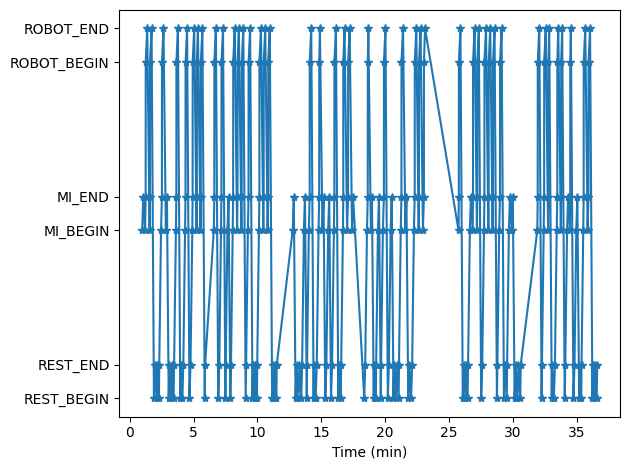

In [26]:
# Plot markers

y_ticks_numbers = sorted(trigger_keys_in_data.keys())
y_ticks_labels = [trigger_keys_in_data[k] for k in y_ticks_numbers]

plt.figure()
plt.plot(clean_marker_timestamps * SEC_TO_MIN, clean_marker_values, '*-')
plt.xlabel('Time (min)')
# plt.ylabel('Marker')
plt.yticks(y_ticks_numbers, y_ticks_labels)
plt.tight_layout()
plt.show()


In [27]:
# Remove aux channels in EEG data

mask_ch_to_keep = ~np.isin(ch_names_all_ch, LIST_CH_TO_REMOVE)

eeg_data = eeg_data_all_ch[mask_ch_to_keep, :]
ch_names = ch_names_all_ch[mask_ch_to_keep]

print(type(eeg_data))
print(eeg_data.shape)
print(eeg_timestamps.shape)
print(ch_names)

<class 'numpy.ndarray'>
(32, 1106756)
(1106756,)
['FP1' 'FPZ' 'FP2' 'F7' 'F3' 'FZ' 'F4' 'F8' 'FC5' 'FC1' 'FC2' 'FC6' 'M1'
 'T7' 'C3' 'CZ' 'C4' 'T8' 'M2' 'CP5' 'CP1' 'CP2' 'CP6' 'P7' 'P3' 'PZ' 'P4'
 'P8' 'POZ' 'O1' 'OZ' 'O2']


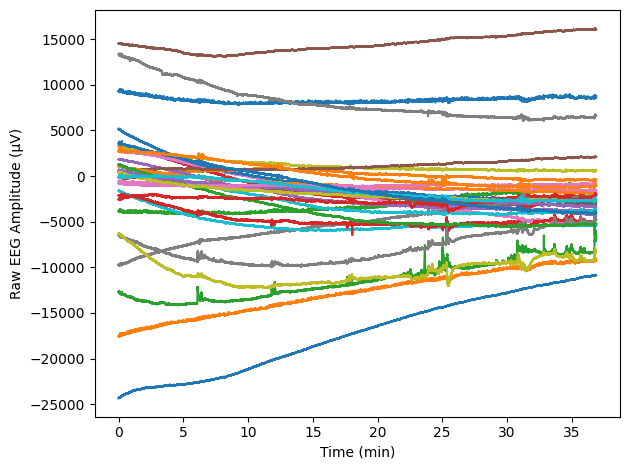

In [28]:
# Plot raw data

plt.figure()
for i in range(len(ch_names)):
    plt.plot(eeg_timestamps * SEC_TO_MIN, eeg_data[i, :])
plt.xlabel('Time (min)')
plt.ylabel('Raw EEG Amplitude (µV)')
plt.tight_layout()
plt.show()

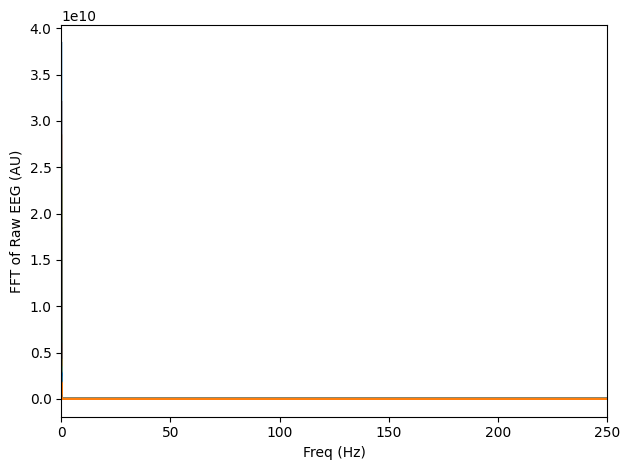

In [29]:
# Plot FFT of raw data

fft_eeg_data = np.abs(np.fft.fft(eeg_data))
fft_freqs = np.fft.fftfreq(fft_eeg_data.shape[1], d=effective_dt)

plt.figure()
for i in range(len(ch_names)):
    plt.plot(fft_freqs, 2 * fft_eeg_data[i, :])
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT of Raw EEG (AU)')
plt.xlim([0, effective_sr / 2])
plt.tight_layout()
plt.show()

In [30]:
# Filter data

butter_sos = signal.butter(BUTTER_ORDER, [BUTTER_L, BUTTER_H] / effective_bw, btype='bandpass', output='sos')
notch_sos = signal.butter(NOTCH_ORDER, [NOTCH_CENTER - NOTCH_HALF_WINDOW, NOTCH_CENTER + NOTCH_HALF_WINDOW] / effective_bw, btype='bandstop', output='sos')

filt_eeg_data = signal.sosfiltfilt(notch_sos, signal.sosfiltfilt(butter_sos, eeg_data))

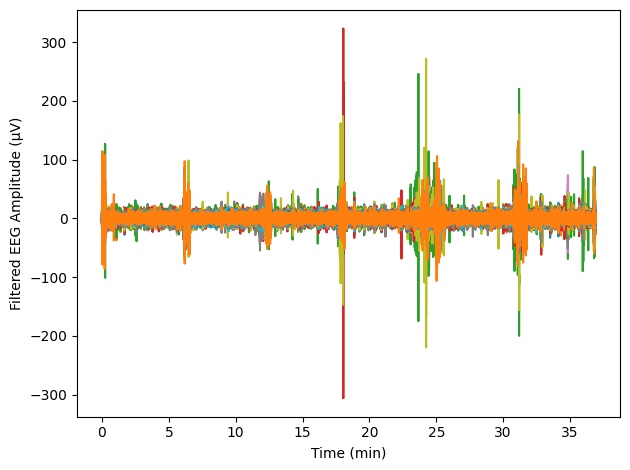

In [31]:
# Plot filtered data

initial_time = eeg_timestamps[0]

plt.figure()
for i in range(len(ch_names)):
    plt.plot(eeg_timestamps * SEC_TO_MIN, filt_eeg_data[i, :])
plt.xlabel('Time (min)')
plt.ylabel('Filtered EEG Amplitude (µV)')
plt.tight_layout()
plt.show()

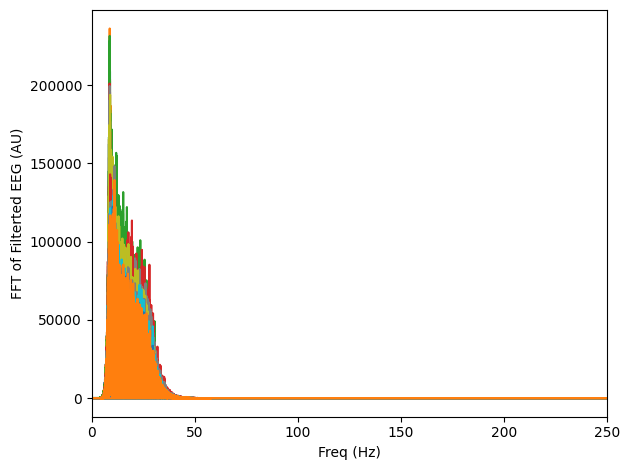

In [32]:
# Plot FFT of filtered data

fft_filt_eeg_data = np.abs(np.fft.fft(filt_eeg_data))
fft_freqs = np.fft.fftfreq(fft_filt_eeg_data.shape[1], d=effective_dt)

plt.figure()
for i in range(len(ch_names)):
    plt.plot(fft_freqs, 2 * fft_filt_eeg_data[i, :])
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT of Filterted EEG (AU)')
plt.xlim([0, effective_sr / 2])
plt.tight_layout()
plt.show()

In [33]:
# Instead of doing this in numpy + scipy, let's move to mne (create info)

rename_ch_names = [ch.replace('FP', 'Fp').replace('Z', 'z') for ch in ch_names]
ch_types = ['eeg'] * len(ch_names)

info = mne.create_info(rename_ch_names, sfreq=effective_sr, ch_types=ch_types)
info.set_montage("standard_1020")

print(info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 500.0 Hz
>


Creating RawArray with float64 data, n_channels=32, n_times=1106756
    Range : 0 ... 1106755 =      0.000 ...  2213.497 secs
Ready.
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
(32, 1106756)


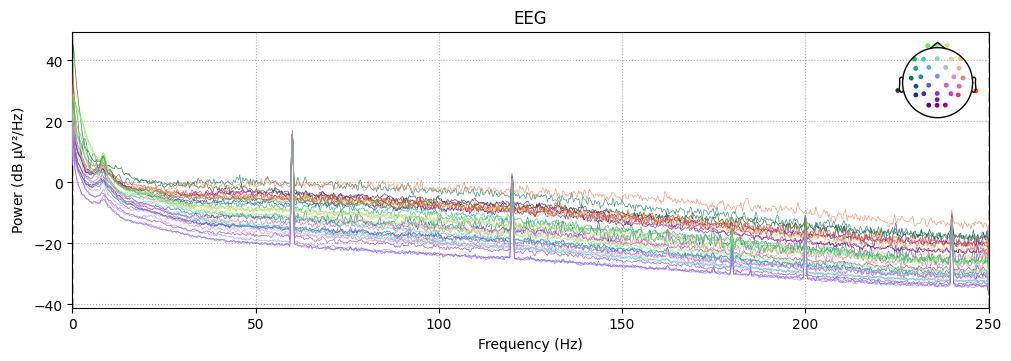

In [34]:
# Create raw data (mne expects it in V, not µV) in mne and plot it in freq

raw_eeg_mne = mne.io.RawArray(eeg_data * MICROVOLTS_TO_VOLTS, info)

raw_eeg_mne.compute_psd().plot()

print(raw_eeg_mne.get_data().shape)

In [35]:
trigger_keys_in_data

{200: 'MI_BEGIN',
 220: 'MI_END',
 300: 'ROBOT_BEGIN',
 320: 'ROBOT_END',
 100: 'REST_BEGIN',
 120: 'REST_END'}

In [36]:
# Create annotations

clean_marker_sample_idxs = clean_marker_timestamps * effective_sr

events = np.zeros(shape=(len(clean_marker_timestamps), 3))
events[:, 0] = clean_marker_sample_idxs.astype(int)
events[:, 2] = clean_marker_values.astype(int)

annotations = mne.annotations_from_events(events=events, sfreq=effective_sr, event_desc=trigger_keys_in_data)
raw_eeg_mne.set_annotations(annotations)

print(raw_eeg_mne.annotations)

<Annotations | 326 segments: MI_BEGIN (60), MI_END (60), REST_BEGIN (60), ...>



---
TODO: casual vs non-casual
---

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 30.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 58 - 62 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 58.00, 62.00 Hz: -6.02, -6.02 dB

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
<class 'mne.io.array.array.RawArray'>
<class 'mne.io.array.array.RawArray'>
Done


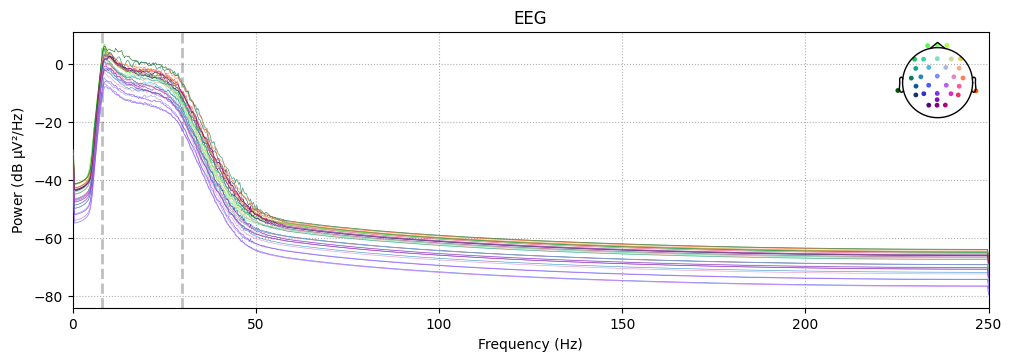

In [45]:
# Filter EEG data in mne and visualize it in freq

# TODO should this filter be casual? In online yeah, but if we are doing offline decoding only?
print()
print('---')
print('TODO: casual vs non-casual')
print('---')
print()

filt_eeg_mne = raw_eeg_mne.copy() # Copy because filter is inplace
filt_eeg_mne.filter(l_freq=BUTTER_L, h_freq=BUTTER_H, method='iir', iir_params=dict(order=BUTTER_ORDER, ftype='butter'))
filt_eeg_mne.filter(l_freq=NOTCH_CENTER + NOTCH_HALF_WINDOW, h_freq=NOTCH_CENTER - NOTCH_HALF_WINDOW, method='iir', iir_params=dict(order=NOTCH_ORDER, ftype='butter'))

filt_eeg_mne.compute_psd().plot()
print(type(raw_eeg_mne))

print(type(filt_eeg_mne))
print('Done') # To avoid printing twice the plots


Using matplotlib as 2D backend.


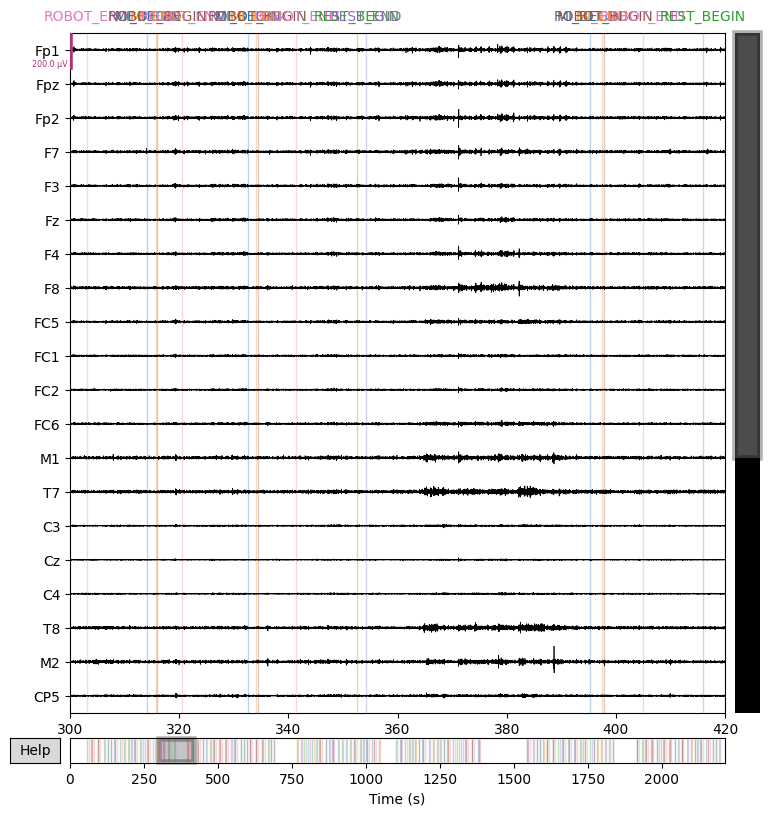

In [38]:
filt_eeg_mne.plot(start=5 * MIN_TO_SEC, duration=2 * MIN_TO_SEC, scalings={'eeg': 100 * MICROVOLTS_TO_VOLTS})
print()

Used Annotations descriptions: ['MI_BEGIN', 'MI_END', 'REST_BEGIN', 'REST_END', 'ROBOT_BEGIN', 'ROBOT_END']
MI: 3.131 ± 1.469 [1.468, 5.046] s
REST:, 3.019 ± 1.487 [1.462, 5.054] s
ROBOT: 6.416 ± 1.380 [2.320, 7.134] s


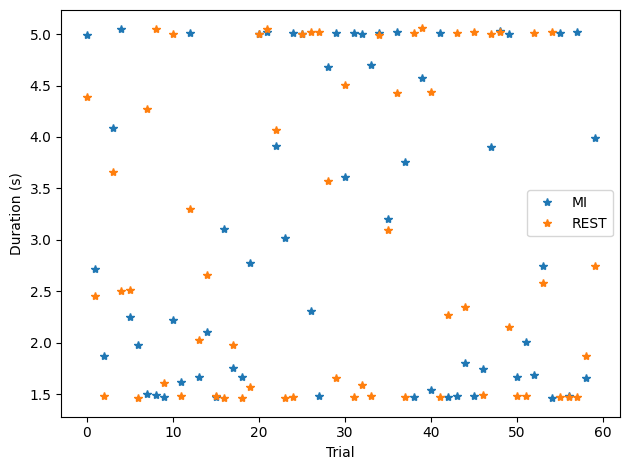

In [39]:
# Visualize length of events

length_events, events_id = mne.events_from_annotations(filt_eeg_mne)

length_events_mi_begin = length_events[np.where(length_events[:, 2] == 1)[0], 0]
length_events_mi_end = length_events[np.where(length_events[:, 2] == 2)[0], 0]
length_events_mi = length_events_mi_end - length_events_mi_begin
time_events_mi = length_events_mi / effective_sr

length_events_rest_begin = length_events[np.where(length_events[:, 2] == 3)[0], 0]
length_events_rest_end = length_events[np.where(length_events[:, 2] == 4)[0], 0]
length_events_rest = length_events_rest_end - length_events_rest_begin
time_events_rest = length_events_rest / effective_sr

length_events_robot_begin = length_events[np.where(length_events[:, 2] == 5)[0], 0]
length_events_robot_end = length_events[np.where(length_events[:, 2] == 6)[0], 0]
length_events_robot = length_events_robot_end - length_events_robot_begin
time_events_robot = length_events_robot / effective_sr

print(f"MI: {np.mean(time_events_mi):.{N_DECIMALS}f} ± {np.std(time_events_mi):.{N_DECIMALS}f} [{np.min(time_events_mi):.{N_DECIMALS}f}, {np.max(time_events_mi):.{N_DECIMALS}f}] s")
print(f"REST:, {np.mean(time_events_rest):.{N_DECIMALS}f} ± {np.std(time_events_rest):.{N_DECIMALS}f} [{np.min(time_events_rest):.{N_DECIMALS}f}, {np.max(time_events_rest):.{N_DECIMALS}f}] s")
print(f"ROBOT: {np.mean(time_events_robot):.{N_DECIMALS}f} ± {np.std(time_events_robot):.{N_DECIMALS}f} [{np.min(time_events_robot):.{N_DECIMALS}f}, {np.max(time_events_robot):.{N_DECIMALS}f}] s")

plt.figure()
plt.plot(time_events_mi, '*', label='MI')
plt.plot(time_events_rest, '*', label='REST')
# plt.plot(time_events_robot, '*', label='ROBOT')
plt.legend()
plt.xlabel('Trial')
plt.ylabel('Duration (s)')
plt.tight_layout()
plt.show()

In [40]:
filt_eeg_mne.set_eeg_reference('average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawArray | 32 x 1106756 (2213.5 s), ~270.2 MB, data loaded>

In [56]:
type(filt_eeg_mne.get_data())

numpy.ndarray

In [58]:
type(np.array([1,2,3]))

numpy.ndarray

In [54]:
filt_eeg_mne.annotations[0]['description']

'MI_BEGIN'

In [42]:
t_min = -1
t_max = 0
baseline_duration = 0.2
t_min -= baseline_duration

epcohs_filt_eeg_mne = mne.Epochs(filt_eeg_mne, mne.events_from_annotations(filt_eeg_mne)[0], event_id=events_id, tmin=t_min, tmax=t_max, baseline=(t_min, t_min + baseline_duration))

epcohs_filt_eeg_mne

Used Annotations descriptions: ['MI_BEGIN', 'MI_END', 'REST_BEGIN', 'REST_END', 'ROBOT_BEGIN', 'ROBOT_END']
Not setting metadata
326 matching events found
Applying baseline correction (mode: mean)
0 projection items activated


<Epochs | 326 events (good & bad), -1.2 – 0 s (baseline -1.2 – -1 s), ~42 kB, data not loaded,
 'MI_BEGIN': 60
 'MI_END': 60
 'REST_BEGIN': 60
 'REST_END': 60
 'ROBOT_BEGIN': 43
 'ROBOT_END': 43>

MI


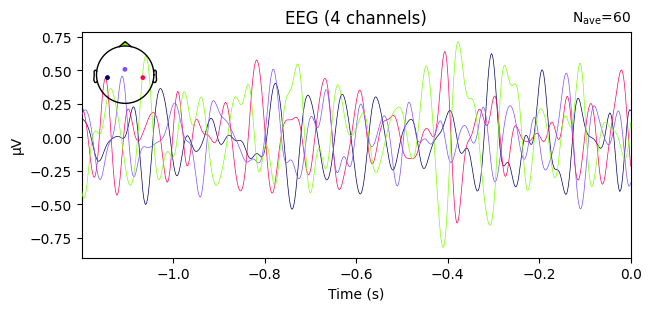

REST


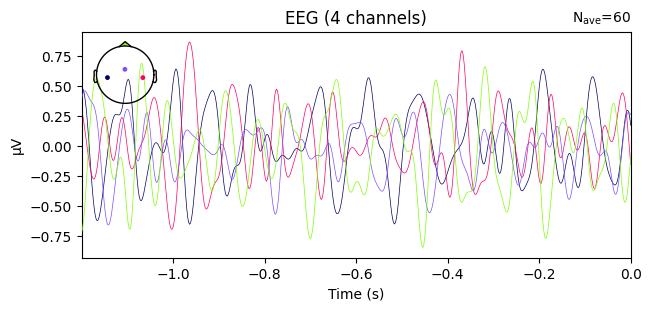


TODO - are you taking windows of time for the topomap???

MI


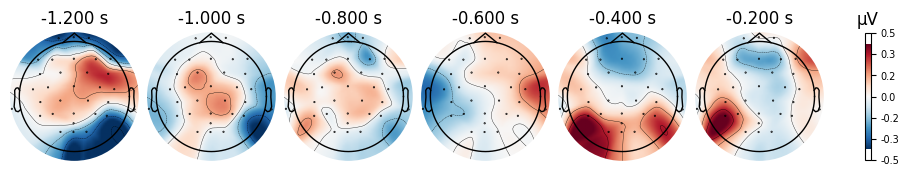

REST


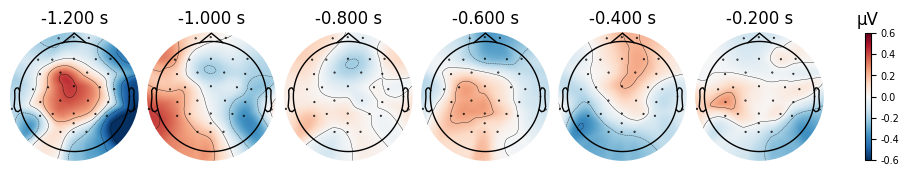

In [43]:
print('MI')
epcohs_filt_eeg_mne['MI_END'].average().plot(picks=['CP5', 'CP6', 'Cz', 'Fpz'])
print('REST')
epcohs_filt_eeg_mne['REST_END'].average().plot(picks=['CP5', 'CP6', 'Cz', 'Fpz'])

window_duration_time = 0.05
time_jump = 0.2
times = np.arange(t_min, t_max, time_jump)

print()
print('TODO - are you taking windows of time for the topomap???')
print()

print('MI')
fig = epcohs_filt_eeg_mne['MI_END'].average().plot_topomap(times=times, average=window_duration_time, show=False)
for each_ax, each_time in zip(fig.axes, times):
    each_ax.set_title(f'{each_time:.{N_DECIMALS}f} s')
plt.show()

print('REST')
fig = epcohs_filt_eeg_mne['REST_END'].average().plot_topomap(times=times, average=window_duration_time, show=False)
for each_ax, each_time in zip(fig.axes, times):
    each_ax.set_title(f'{each_time:.{N_DECIMALS}f} s')
plt.show()

print()